# Benchmark de Modelos de Embedding para RAG

Compara **4 modelos** em três eixos:

| Dimensão | Métricas |
|---|---|
| Qualidade de recuperação | MRR@10, Recall@5, Recall@10, NDCG@10 |
| Qualidade semântica | Silhouette, gap intra/inter-cluster (K-Means k=5) |
| Eficiência | Latência (ms/chunk), throughput, tamanho em disco, custo |

**Corpus**: Attention Is All You Need · BERT · RAG (3 papers em `../data/papers/`)

| Modelo | Tipo |
|---|---|
| `all-MiniLM-L6-v2` | leve, sem GPU |
| `bge-large-en-v1.5` | grande, GPU recomendada |
| `e5-large-v2` | grande, prefixos passage/query |
| `gemini-embedding-001` | API Google |

In [1]:
import os, sys, time, logging, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import psutil
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("⚠ umap-learn não instalado: pip install umap-learn")

try:
    from google import genai as google_genai
    HAS_GEMINI_SDK = True
except ImportError:
    HAS_GEMINI_SDK = False
    print("⚠ google-genai não instalado: pip install google-genai")

sys.path.insert(0, str(Path('..').resolve()))
warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("emb_bench")
print("Imports OK")

c:\Users\luana\OneDrive\Projects\winnin\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
# ── Configuração ───────────────────────────────────────────────────────────

PAPERS = {
    "attention": {
        "url":   "https://arxiv.org/pdf/1706.03762",
        "title": "Attention Is All You Need",
    },
    "rag": {
        "url":   "https://arxiv.org/pdf/2005.11401",
        "title": "Retrieval-Augmented Generation",
    },
    "bert": {
        "url":   "https://arxiv.org/pdf/1810.04805",
        "title": "BERT",
    },
}

MODELS = {
    "minilm-l6":  "sentence-transformers/all-MiniLM-L6-v2",
    "bge-large":  "BAAI/bge-large-en-v1.5",
    "e5-large":   "intfloat/e5-large-v2",
    "gemini-emb": "gemini-embedding-001",
}

CHUNK_SIZE    = 512
CHUNK_OVERLAP = 64

PDF_DIR   = Path("../data/papers")
CACHE_DIR = Path("embed_cache")
CACHE_DIR.mkdir(exist_ok=True)

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    try:
        from dotenv import load_dotenv
        load_dotenv("../.env")
        GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
    except ImportError:
        pass

HAS_GEMINI = HAS_GEMINI_SDK and bool(GEMINI_API_KEY)
if HAS_GEMINI:
    gemini_client = google_genai.Client(api_key=GEMINI_API_KEY)
    logger.info("Gemini API configurada.")
else:
    logger.warning("Gemini será pulado — GEMINI_API_KEY ausente ou SDK não instalado.")

ACTIVE_MODELS = {
    k: v for k, v in MODELS.items()
    if not (k == "gemini-emb" and not HAS_GEMINI)
}
print(f"Modelos ativos: {list(ACTIVE_MODELS.keys())}")

16:28:42 | INFO     | emb_bench | Gemini API configurada.


Modelos ativos: ['minilm-l6', 'bge-large', 'e5-large', 'gemini-emb']


## 1. Ingestão de Dados
Download dos PDFs → extração de texto → chunking com overlap.

In [3]:
# ── Download ────────────────────────────────────────────────────────────────

def download_pdf(url: str, dest: Path) -> Path:
    if dest.exists():
        logger.info("Já existe: %s", dest.name)
        return dest
    logger.info("Baixando %s ...", url)
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=60, stream=True)
    r.raise_for_status()
    dest.parent.mkdir(parents=True, exist_ok=True)
    with open(dest, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    logger.info("Salvo %s (%.0f KB)", dest.name, dest.stat().st_size / 1024)
    return dest


# ── Extração de texto com Docling ───────────────────────────────────────────

def extract_text(pdf_path: Path) -> str:
    from docling.document_converter import DocumentConverter
    result = DocumentConverter().convert(str(pdf_path))
    return result.document.export_to_markdown()


# ── Chunking com overlap ────────────────────────────────────────────────────

def chunk_text(
    text: str,
    paper_id: str,
    chunk_size: int = CHUNK_SIZE,
    overlap: int = CHUNK_OVERLAP,
) -> list[dict]:
    ws = int(chunk_size / 1.3)
    wo = int(overlap  / 1.3)
    words = text.split()
    chunks, start, idx = [], 0, 0
    while start < len(words):
        end = min(start + ws, len(words))
        chunks.append({
            "id":       f"{paper_id}__{idx:04d}",
            "paper_id": paper_id,
            "text":     " ".join(words[start:end]),
        })
        idx += 1
        if end == len(words):
            break
        start += ws - wo
    return chunks


# ── Pipeline completo ───────────────────────────────────────────────────────

def ingest_all() -> list[dict]:
    all_chunks = []
    for paper_id, info in PAPERS.items():
        pdf = PDF_DIR / f"{paper_id}.pdf"
        download_pdf(info["url"], pdf)
        text = extract_text(pdf)
        cks  = chunk_text(text, paper_id)
        all_chunks.extend(cks)
        logger.info("'%s': %d chars → %d chunks", paper_id, len(text), len(cks))
    logger.info("Total: %d chunks", len(all_chunks))
    return all_chunks

In [4]:
chunks      = ingest_all()
chunk_texts = [c["text"] for c in chunks]
paper_ids   = [c["paper_id"] for c in chunks]

print(f"\nChunks por paper:")
for pid in PAPERS:
    n = sum(1 for c in chunks if c["paper_id"] == pid)
    avg_words = np.mean([len(c["text"].split()) for c in chunks if c["paper_id"] == pid])
    print(f"  {pid:10s}: {n:3d} chunks  (~{avg_words:.0f} palavras/chunk)")
print(f"  {'TOTAL':10s}: {len(chunks):3d} chunks")

16:28:42 | INFO     | emb_bench | Já existe: attention.pdf
16:28:43 | INFO     | docling.datamodel.document | detected formats: [<InputFormat.PDF: 'pdf'>]
16:28:43 | INFO     | docling.document_converter | Going to convert document batch...
16:28:43 | INFO     | docling.document_converter | Initializing pipeline for StandardPdfPipeline with options hash 80a8a1322ca5ef46817c7adbf875fff6
16:28:43 | INFO     | docling.models.factories.base_factory | Loading plugin 'docling_defaults'
16:28:43 | INFO     | docling.models.factories | Registered picture descriptions: ['picture_description_vlm_engine', 'vlm', 'api']
16:28:43 | INFO     | docling.models.factories.base_factory | Loading plugin 'docling_defaults'
16:28:43 | INFO     | docling.models.factories | Registered ocr engines: ['auto', 'easyocr', 'kserve_v2_ocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
16:28:44 | INFO     | docling.utils.accelerator_utils | Accelerator device: 'cpu'
[INFO] 2026-04-24 16:28:44,095 [RapidOCR] base.p


Chunks por paper:
  attention :  20 chunks  (~379 palavras/chunk)
  rag       :  31 chunks  (~382 palavras/chunk)
  bert      :  31 chunks  (~382 palavras/chunk)
  TOTAL     :  82 chunks


## 2. Geração de Embeddings

Cada modelo é carregado, embeda todos os chunks e registra latência + RAM.
Os embeddings são cacheados em `embed_cache/` para evitar reprocessamento.

In [5]:
_st_model_cache: dict = {}


def get_st_model(model_id: str) -> SentenceTransformer:
    if model_id not in _st_model_cache:
        _st_model_cache[model_id] = SentenceTransformer(model_id)
    return _st_model_cache[model_id]


def cache_load(key: str):
    p = CACHE_DIR / f"{key}.pkl"
    if p.exists():
        logger.info("Cache hit: %s", key)
        with open(p, "rb") as f:
            return pickle.load(f)
    return None


def cache_save(key: str, obj):
    with open(CACHE_DIR / f"{key}.pkl", "wb") as f:
        pickle.dump(obj, f)


# ── Open-source embedding ───────────────────────────────────────────────────

def embed_st(
    model_short: str,
    texts: list[str],
    doc_prefix: str = "",
    batch_size: int = 8,
) -> dict:
    model_id = MODELS[model_short]
    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss / (1024 ** 2)

    logger.info("Carregando %s ...", model_id)
    model = get_st_model(model_id)

    to_encode = [f"{doc_prefix}{t}" for t in texts] if doc_prefix else texts

    logger.info("Encodando %d textos ...", len(texts))
    t0   = time.perf_counter()
    embs = model.encode(
        to_encode,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    elapsed = time.perf_counter() - t0

    mem_after = proc.memory_info().rss / (1024 ** 2)
    n = len(texts)

    return {
        "model_short":  model_short,
        "model_id":     model_id,
        "embeddings":   embs.astype(np.float32),
        "dim":          embs.shape[1],
        "n":            n,
        "total_s":      elapsed,
        "latency_ms":   (elapsed * 1000) / n,
        "throughput":   n / elapsed,
        "ram_delta_mb": mem_after - mem_before,
        "doc_prefix":   doc_prefix,
    }


def embed_gemini(
    texts: list[str],
    task_type: str = "RETRIEVAL_DOCUMENT",
    batch_size: int = 50,
    sleep_s: float = 1.0,
) -> dict:
    if not HAS_GEMINI:
        raise RuntimeError("Gemini nao disponivel.")

    gemini_model = MODELS["gemini-emb"]
    logger.info("Embeddings Gemini (%s): %d textos (task=%s) ...", gemini_model, len(texts), task_type)
    all_embs, t0 = [], time.perf_counter()

    for start in tqdm(range(0, len(texts), batch_size), desc=f"Gemini ({gemini_model})"):
        batch = texts[start : start + batch_size]
        for attempt in range(6):
            try:
                resp = gemini_client.models.embed_content(
                    model=gemini_model,
                    contents=batch,
                    config={"task_type": task_type},
                )
                all_embs.extend([e.values for e in resp.embeddings])
                break
            except Exception as exc:
                wait = 2 ** attempt
                logger.warning("Gemini erro (tentativa %d/6): %s - aguardando %ds", attempt + 1, exc, wait)
                time.sleep(wait)
        else:
            raise RuntimeError(f"Gemini falhou apos 6 tentativas no batch {start}")
        if start + batch_size < len(texts):
            time.sleep(sleep_s)

    elapsed = time.perf_counter() - t0
    embs    = np.array(all_embs, dtype=np.float32)
    norms   = np.linalg.norm(embs, axis=1, keepdims=True)
    embs   /= np.where(norms > 0, norms, 1)

    approx_tokens      = sum(len(t) for t in texts) / 4
    cost_usd           = (approx_tokens / 1_000_000) * 0.10
    cost_per_1m_chunks = cost_usd / len(texts) * 1_000_000
    n = len(texts)

    return {
        "model_short":     "gemini-emb",
        "model_id":        gemini_model,
        "embeddings":      embs,
        "dim":             embs.shape[1],
        "n":               n,
        "total_s":         elapsed,
        "latency_ms":      (elapsed * 1000) / n,
        "throughput":      n / elapsed,
        "ram_delta_mb":    0.0,
        "cost_usd":        cost_usd,
        "cost_per_1m_usd": cost_per_1m_chunks,
        "doc_prefix":      "",
    }

In [6]:
embedding_results: dict[str, dict] = {}

for _key in ACTIVE_MODELS:
    if (_cached := cache_load(_key)) is not None:
        if _cached["embeddings"].shape[0] != len(chunk_texts):
            logger.warning(
                "%s: cache desatualizado (%d embeddings vs %d chunks) — re-embedando.",
                _key, _cached["embeddings"].shape[0], len(chunk_texts),
            )
            (CACHE_DIR / f"{_key}.pkl").unlink()
        else:
            embedding_results[_key] = _cached
            print(f"✓ {_key} (cache): dim={_cached['dim']}")
            continue

    if _key == "gemini-emb":
        result = embed_gemini(chunk_texts)
    elif _key == "e5-large":
        result = embed_st(_key, chunk_texts, doc_prefix="passage: ")
    else:
        result = embed_st(_key, chunk_texts)

    embedding_results[_key] = result
    cache_save(_key, result)
    print(f"✓ {_key}: dim={result['dim']}")

print(f"\nEmbeddings prontos: {list(embedding_results.keys())}")

16:30:19 | INFO     | emb_bench | Cache hit: minilm-l6
16:30:19 | WARNING  | emb_bench | minilm-l6: cache desatualizado (77 embeddings vs 82 chunks) — re-embedando.
16:30:19 | INFO     | emb_bench | Carregando sentence-transformers/all-MiniLM-L6-v2 ...
16:30:19 | INFO     | sentence_transformers.base.model | No device provided, using cpu
16:30:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
16:30:19 | WARNING  | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
16:30:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
16:30:20 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transforme

✓ minilm-l6: dim=384


16:30:27 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
16:30:27 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
16:30:27 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
16:30:27 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
16:30:27 | INFO     | sentence_transformers.base.model | Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
16:30:27 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "H

✓ bge-large: dim=1024


16:32:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/intfloat/e5-large-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
16:32:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/e5-large-v2/f169b11e22de13617baa190a028a32f3493550b6/modules.json "HTTP/1.1 200 OK"
16:32:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/intfloat/e5-large-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 404 Not Found"
16:32:19 | INFO     | sentence_transformers.base.model | Loading SentenceTransformer model from intfloat/e5-large-v2.
16:32:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/intfloat/e5-large-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 404 Not Found"
16:32:19 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/intfloat/e5-large-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
16:32:19 | INFO     | httpx | HTTP Request: HEAD https://hu

✓ e5-large: dim=1024


Gemini (gemini-embedding-001): 100%|██████████| 2/2 [00:05<00:00,  2.82s/it]

✓ gemini-emb: dim=3072

Embeddings prontos: ['minilm-l6', 'bge-large', 'e5-large', 'gemini-emb']


## 3. Índices FAISS

`IndexFlatIP` com vetores normalizados equivale a busca por similaridade cosseno.

In [7]:
def build_faiss_index(embs: np.ndarray) -> faiss.Index:
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs.astype(np.float32))
    return idx


faiss_indices: dict[str, faiss.Index] = {
    name: build_faiss_index(r["embeddings"])
    for name, r in embedding_results.items()
}

for name, idx in faiss_indices.items():
    print(f"  {name:12s}  {idx.ntotal} vetores  dim={idx.d}")

  minilm-l6     82 vetores  dim=384
  bge-large     82 vetores  dim=1024
  e5-large      82 vetores  dim=1024
  gemini-emb    82 vetores  dim=3072


## 4. Benchmark de Recuperação

**20 queries** com ground-truth gerado por keyword matching sobre os chunks reais.
Um chunk é relevante se pertence ao paper esperado E contém ≥ N keywords.

In [8]:
# ── Ground truth queries ───────────────────────────────────────────────────

QUERY_SPECS = [
    # --- Attention Is All You Need ---
    {"query": "How does scaled dot-product attention work?",
     "papers": ["attention"], "keywords": ["scaled dot-product", "query", "key", "value", "softmax"], "min_hits": 3},
    {"query": "What is multi-head attention in the transformer?",
     "papers": ["attention"], "keywords": ["multi-head", "head", "concatenat", "project"], "min_hits": 2},
    {"query": "How are positional encodings computed?",
     "papers": ["attention"], "keywords": ["positional", "encoding", "sine", "cosine"], "min_hits": 2},
    {"query": "What is the encoder-decoder structure in transformers?",
     "papers": ["attention"], "keywords": ["encoder", "decoder", "stack", "self-attention"], "min_hits": 3},
    {"query": "What optimizer and training schedule were used for the transformer?",
     "papers": ["attention"], "keywords": ["adam", "warmup", "learning rate", "training"], "min_hits": 2},
    # --- BERT ---
    {"query": "How does BERT use masked language modeling for pre-training?",
     "papers": ["bert"], "keywords": ["masked", "language model", "mlm", "mask", "token"], "min_hits": 2},
    {"query": "What is next sentence prediction in BERT?",
     "papers": ["bert"], "keywords": ["next sentence", "nsp", "sentence", "pair"], "min_hits": 2},
    {"query": "How is BERT fine-tuned for downstream classification tasks?",
     "papers": ["bert"], "keywords": ["fine-tun", "classification", "glue", "squad"], "min_hits": 2},
    {"query": "What is the BERT input representation with WordPiece?",
     "papers": ["bert"], "keywords": ["wordpiece", "token", "segment", "embed", "input"], "min_hits": 2},
    {"query": "What benchmark results did BERT achieve?",
     "papers": ["bert"], "keywords": ["state-of-the-art", "glue", "squad", "accuracy", "f1"], "min_hits": 3},
    # --- RAG ---
    {"query": "How does RAG combine parametric and non-parametric memory?",
     "papers": ["rag"], "keywords": ["parametric", "non-parametric", "memory", "retriev"], "min_hits": 2},
    {"query": "What is the difference between RAG-Sequence and RAG-Token?",
     "papers": ["rag"], "keywords": ["rag-sequence", "rag-token", "marginalize"], "min_hits": 2},
    {"query": "How does RAG use FAISS for dense retrieval?",
     "papers": ["rag"], "keywords": ["faiss", "dense", "retriev", "passage", "index"], "min_hits": 2},
    {"query": "What seq2seq generator does RAG use for answer generation?",
     "papers": ["rag"], "keywords": ["bart", "seq2seq", "generat", "token"], "min_hits": 2},
    {"query": "How is the RAG model trained end-to-end?",
     "papers": ["rag"], "keywords": ["end-to-end", "train", "gradient", "retriever", "loss"], "min_hits": 2},
    # --- Cross-paper ---
    {"query": "How do attention mechanisms improve information retrieval?",
     "papers": ["attention", "rag", "bert"], "keywords": ["attention", "retriev", "relevant", "query"], "min_hits": 3},
    {"query": "What encoder representations are used for dense search?",
     "papers": ["rag", "bert"], "keywords": ["encoder", "dense", "embedding", "retriev"], "min_hits": 2},
    {"query": "How are knowledge-intensive NLP tasks addressed?",
     "papers": ["rag", "bert"], "keywords": ["knowledge", "open-domain", "question answer", "fact"], "min_hits": 2},
    {"query": "What datasets were used to train and evaluate these models?",
     "papers": ["attention", "bert", "rag"], "keywords": ["dataset", "train", "wmt", "squad", "bookcorpus"], "min_hits": 2},
    {"query": "What are the main contributions of these papers?",
     "papers": ["attention", "bert", "rag"], "keywords": ["propose", "novel", "outperform", "state-of-the-art"], "min_hits": 2},
]

assert len(QUERY_SPECS) == 20


def build_ground_truth(chunks: list[dict], specs: list[dict]) -> list[set[int]]:
    gt = []
    for spec in specs:
        relevant = set()
        for i, c in enumerate(chunks):
            if c["paper_id"] not in spec["papers"]:
                continue
            tl = c["text"].lower()
            hits = sum(1 for kw in spec["keywords"] if kw in tl)
            if hits >= spec["min_hits"]:
                relevant.add(i)
        gt.append(relevant)
    sizes = [len(s) for s in gt]
    empty = sum(1 for s in gt if not s)
    print(f"Ground truth: avg {np.mean(sizes):.1f} chunks relevantes/query  "
          f"(min={min(sizes)}, max={max(sizes)})  {empty} queries sem match")
    return gt


ground_truth = build_ground_truth(chunks, QUERY_SPECS)

Ground truth: avg 12.5 chunks relevantes/query  (min=0, max=24)  1 queries sem match


In [9]:
def mrr_at_k(retrieved: list[int], relevant: set[int], k: int = 10) -> float:
    for rank, idx in enumerate(retrieved[:k], 1):
        if idx in relevant:
            return 1.0 / rank
    return 0.0


def recall_at_k(retrieved: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    return sum(1 for i in retrieved[:k] if i in relevant) / len(relevant)


def ndcg_at_k(retrieved: list[int], relevant: set[int], k: int = 10) -> float:
    if not relevant:
        return 0.0
    dcg  = sum(1.0 / np.log2(r + 1) for r, i in enumerate(retrieved[:k], 1) if i in relevant)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, min(len(relevant), k) + 1))
    return dcg / idcg if idcg else 0.0


def embed_queries(model_short: str, query_texts: list[str]) -> np.ndarray:
    if model_short == "gemini-emb":
        r = embed_gemini(query_texts, task_type="RETRIEVAL_QUERY", batch_size=20, sleep_s=0.5)
        return r["embeddings"]

    model = get_st_model(MODELS[model_short])

    if model_short == "e5-large":
        texts = [f"query: {q}" for q in query_texts]
    else:
        texts = query_texts

    return model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True,
    ).astype(np.float32)


def run_benchmark(
    model_short: str,
    index: faiss.Index,
    query_specs: list[dict],
    gt: list[set[int]],
    k: int = 10,
) -> dict:
    q_texts = [s["query"] for s in query_specs]
    q_embs  = embed_queries(model_short, q_texts)

    mrrs, r5s, r10s, ndcgs = [], [], [], []
    for i, (spec, relevant) in enumerate(zip(query_specs, gt)):
        if not relevant:
            continue
        _, idxs = index.search(q_embs[i:i+1], k)
        ret = idxs[0].tolist()
        mrrs.append(mrr_at_k(ret, relevant, k))
        r5s.append(recall_at_k(ret, relevant, 5))
        r10s.append(recall_at_k(ret, relevant, 10))
        ndcgs.append(ndcg_at_k(ret, relevant, k))

    return {
        "model":     model_short,
        "MRR@10":    float(np.mean(mrrs)),
        "Recall@5":  float(np.mean(r5s)),
        "Recall@10": float(np.mean(r10s)),
        "NDCG@10":   float(np.mean(ndcgs)),
        "n_queries": len(mrrs),
    }

In [10]:
benchmark_results: dict[str, dict] = {}

for name in embedding_results:
    logger.info("Benchmark: %s ...", name)
    bm = run_benchmark(name, faiss_indices[name], QUERY_SPECS, ground_truth)
    benchmark_results[name] = bm

df_bench = (
    pd.DataFrame(list(benchmark_results.values()))
    .set_index("model")
    .drop(columns="n_queries")
    .sort_values("NDCG@10", ascending=False)
)

print("\n── Retrieval Benchmark ──────────────────────────────────────")
display(df_bench.style
    .background_gradient(cmap="YlGn", subset=["MRR@10", "NDCG@10"])
    .background_gradient(cmap="Blues", subset=["Recall@5", "Recall@10"])
    .format("{:.4f}")
)

16:34:18 | INFO     | emb_bench | Benchmark: minilm-l6 ...
16:34:18 | INFO     | emb_bench | Benchmark: bge-large ...
16:34:19 | INFO     | emb_bench | Benchmark: e5-large ...
16:34:20 | INFO     | emb_bench | Benchmark: gemini-emb ...
16:34:20 | INFO     | emb_bench | Embeddings Gemini (gemini-embedding-001): 20 textos (task=RETRIEVAL_QUERY) ...
Gemini (gemini-embedding-001): 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


── Retrieval Benchmark ──────────────────────────────────────


,MRR@10,Recall@5,Recall@10,NDCG@10
model,,,,
gemini-emb,0.9211,0.3627,0.5279,0.7509
e5-large,0.8105,0.3074,0.5094,0.6812
bge-large,0.8759,0.2985,0.4181,0.6302
minilm-l6,0.8421,0.2730,0.4233,0.6032


## 5. Qualidade Semântica — K-Means (k=5)

Avalia o quanto os embeddings agrupam textos semanticamente similares:
- **Silhouette**: qualidade global dos clusters
- **Gap intra−inter**: vetores do mesmo cluster devem ser mais próximos entre si do que de clusters diferentes
- **Paper purity**: clusters devem alinhar com o paper de origem

In [11]:
def cluster_analysis(embs: np.ndarray, paper_ids_list: list[str], model_name: str, k: int = 5) -> dict:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embs)
    sil    = silhouette_score(embs, labels, sample_size=min(1000, len(embs)), random_state=42)

    # Intra-cluster similarity (amostra até 50 pontos por cluster)
    intra = []
    for c in range(k):
        ce = embs[labels == c][:50]
        if len(ce) < 2:
            continue
        m = ce @ ce.T
        intra.extend(m[np.triu_indices(len(ce), k=1)].tolist())

    # Inter-cluster similarity (amostra 20 pontos de cada par de clusters)
    inter = []
    for c1 in range(k):
        for c2 in range(c1 + 1, k):
            e1 = embs[labels == c1][:20]
            e2 = embs[labels == c2][:20]
            if len(e1) == 0 or len(e2) == 0:
                continue
            inter.extend((e1 @ e2.T).flatten().tolist())

    # Paper purity: fração do paper dominante em cada cluster
    pa     = np.array(paper_ids_list)
    purity = np.mean([
        max(np.sum(pa[labels == c] == p) for p in PAPERS) / np.sum(labels == c)
        for c in range(k) if np.sum(labels == c) > 0
    ])

    return {
        "model":       model_name,
        "silhouette":  float(sil),
        "intra_sim":   float(np.mean(intra)),
        "inter_sim":   float(np.mean(inter)),
        "gap":         float(np.mean(intra) - np.mean(inter)),
        "purity":      float(purity),
        "labels":      labels,
    }


cluster_results: dict[str, dict] = {}
for name, r in embedding_results.items():
    logger.info("K-Means: %s ...", name)
    cluster_results[name] = cluster_analysis(r["embeddings"], paper_ids, name)

df_cluster = pd.DataFrame([
    {
        "Modelo":           cr["model"],
        "Silhouette":       round(cr["silhouette"], 4),
        "Intra-sim":        round(cr["intra_sim"], 4),
        "Inter-sim":        round(cr["inter_sim"], 4),
        "Gap (↑ melhor)":   round(cr["gap"], 4),
        "Paper Purity":     round(cr["purity"], 4),
    }
    for cr in cluster_results.values()
]).sort_values("Gap (↑ melhor)", ascending=False)

print("\n── Análise de Clusters ─────────────────────────────────────")
display(df_cluster.style
    .background_gradient(cmap="YlGn", subset=["Gap (↑ melhor)", "Silhouette"])
    .background_gradient(cmap="Purples", subset=["Paper Purity"])
    .hide(axis="index")
)

16:34:21 | INFO     | emb_bench | K-Means: minilm-l6 ...
16:34:23 | INFO     | emb_bench | K-Means: bge-large ...
16:34:23 | INFO     | emb_bench | K-Means: e5-large ...
16:34:23 | INFO     | emb_bench | K-Means: gemini-emb ...



── Análise de Clusters ─────────────────────────────────────


Modelo,Silhouette,Intra-sim,Inter-sim,Gap (↑ melhor),Paper Purity
minilm-l6,0.056400,0.519800,0.383300,0.136500,0.788000
gemini-emb,0.160000,0.886200,0.799900,0.086300,0.912500
bge-large,0.091500,0.795900,0.725800,0.070100,0.851100
e5-large,0.109300,0.886700,0.852700,0.034000,0.877300


## 6. Visualização UMAP 2D

Projeção 2D dos embeddings colorida por paper de origem.
Clusters bem separados indicam melhor discriminação semântica.

16:34:23 | INFO     | emb_bench | UMAP: minilm-l6 ...
16:34:31 | INFO     | emb_bench | UMAP: bge-large ...
16:34:32 | INFO     | emb_bench | UMAP: e5-large ...
16:34:32 | INFO     | emb_bench | UMAP: gemini-emb ...


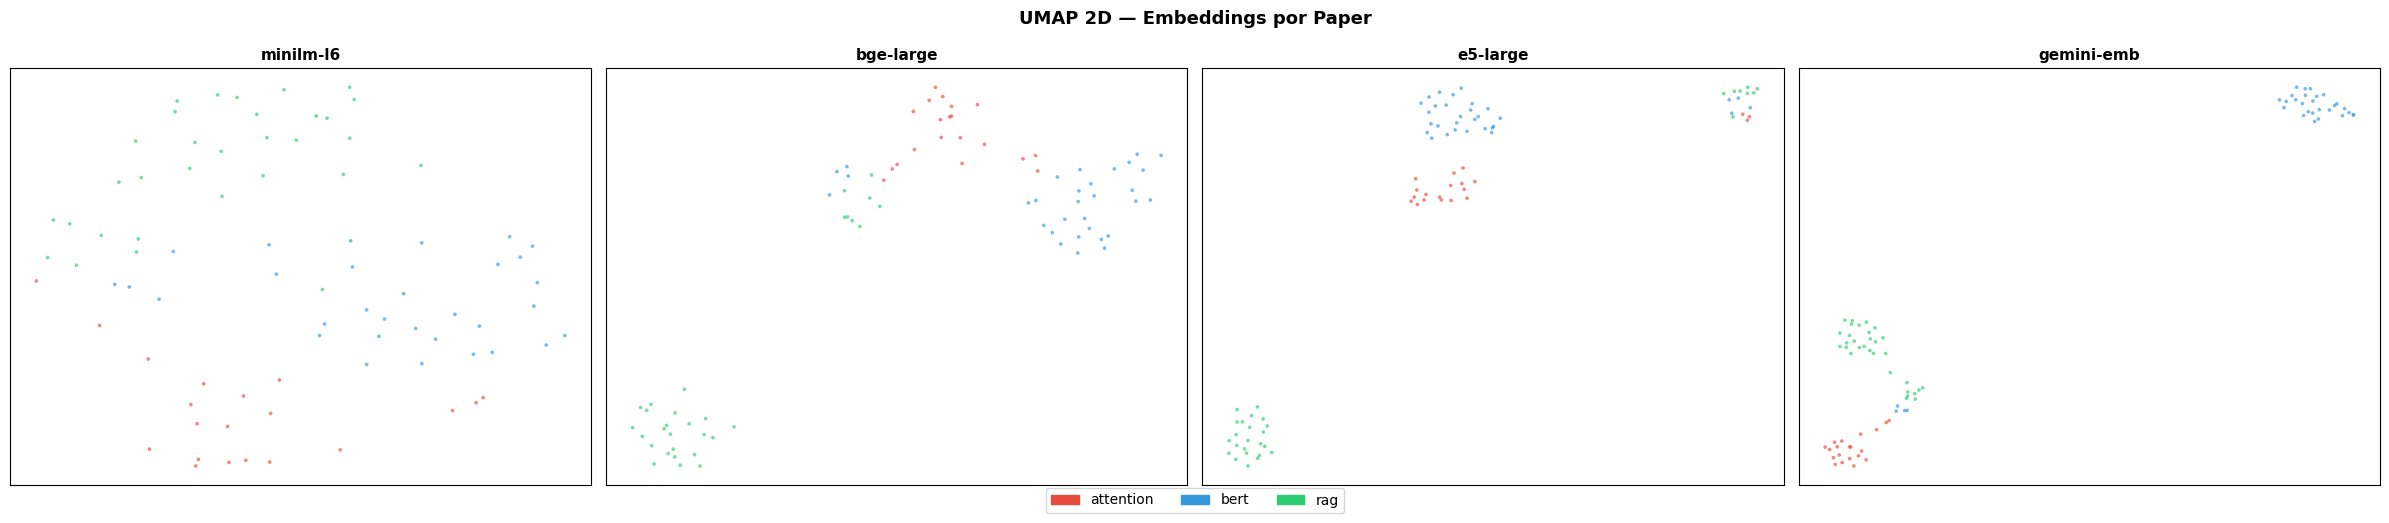

In [12]:
if not HAS_UMAP:
    print("umap-learn não instalado: pip install umap-learn")
else:
    COLORS = {"attention": "#e74c3c", "bert": "#3498db", "rag": "#2ecc71"}
    N_MOD  = len(embedding_results)

    fig, axes = plt.subplots(1, N_MOD, figsize=(6 * N_MOD, 5))
    if N_MOD == 1:
        axes = [axes]

    rng = np.random.default_rng(42)

    for ax, (name, r) in zip(axes, embedding_results.items()):
        embs = r["embeddings"]
        pids = paper_ids

        # Amostrar para velocidade
        if len(embs) > 800:
            idx   = rng.choice(len(embs), 800, replace=False)
            embs  = embs[idx]
            pids  = [paper_ids[i] for i in idx]

        logger.info("UMAP: %s ...", name)
        coords = umap.UMAP(
            n_components=2, random_state=42, n_neighbors=15, min_dist=0.1
        ).fit_transform(embs)

        ax.scatter(
            coords[:, 0], coords[:, 1],
            c=[COLORS[p] for p in pids],
            s=7, alpha=0.65, linewidths=0,
        )
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])

    fig.legend(
        handles=[mpatches.Patch(color=c, label=p) for p, c in COLORS.items()],
        loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04),
    )
    fig.suptitle("UMAP 2D — Embeddings por Paper", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("umap_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Análise de Eficiência

In [13]:
def disk_size_mb(model_hf_id: str) -> float:
    """Tamanho dos pesos do modelo no cache HuggingFace."""
    slug = "models--" + model_hf_id.replace("/", "--")
    base = Path.home() / ".cache" / "huggingface" / "hub" / slug
    if not base.exists():
        return -1.0
    total = sum(
        f.stat().st_size
        for ext in ("*.bin", "*.safetensors", "*.pt")
        for f in base.rglob(ext)
    )
    return total / (1024 ** 2)


rows = []
for name, r in embedding_results.items():
    is_api = name == "gemini-emb"
    size   = "API" if is_api else f"{disk_size_mb(r['model_id']):.0f} MB"
    cost   = (
        f"${r.get('cost_per_1m_usd', 0):.2f}"
        if is_api else "$0 (local)"
    )
    rows.append({
        "Modelo":             name,
        "Dim":                r["dim"],
        "Latência (ms/chunk)": round(r["latency_ms"], 2),
        "Throughput (c/s)":   round(r["throughput"], 1),
        "RAM Δ (MB)":         round(r["ram_delta_mb"], 0),
        "Tamanho disco":      size,
        "Custo / 1M chunks":  cost,
    })

df_eff = pd.DataFrame(rows).set_index("Modelo")
print("\n── Eficiência ──────────────────────────────────────────────")
display(df_eff.style.background_gradient(
    cmap="YlOrRd_r",
    subset=[c for c in ["Latência (ms/chunk)", "Throughput (c/s)"] if c in df_eff.columns]
))


── Eficiência ──────────────────────────────────────────────


,Dim,Latência (ms/chunk),Throughput (c/s),RAM Δ (MB),Tamanho disco,Custo / 1M chunks
Modelo,,,,,,
minilm-l6,384,32.180000,31.100000,9.000000,87 MB,$0 (local)
bge-large,1024,1304.040000,0.800000,1185.000000,1279 MB,$0 (local)
e5-large,1024,1330.880000,0.800000,1206.000000,1279 MB,$0 (local)
gemini-emb,3072,68.720000,14.600000,0.000000,API,$60.87


## 8. Relatório Final — Radar + Recomendação

In [14]:
# ── Normalização min-max ───────────────────────────────────────────────────

def minmax(vals: list[float], higher_better: bool = True) -> list[float]:
    a = np.array(vals, dtype=float)
    lo, hi = a.min(), a.max()
    if hi == lo:
        return [0.5] * len(vals)
    n = (a - lo) / (hi - lo)
    return (n if higher_better else 1 - n).tolist()


models_list = list(embedding_results.keys())

# 1.0 = muito fácil de deployar/grátis, 0.0 = difícil/caro
DEPLOY_EASE = {
    "minilm-l6":  1.00,  # 22 MB, sem GPU
    "bge-large":  0.40,  # 1.3 GB, GPU recomendada
    "e5-large":   0.40,  # 1.3 GB, GPU recomendada
    "gemini-emb": 0.70,  # API, sem infra local
}
COST_SCORE = {
    "minilm-l6":  1.00,  # grátis
    "bge-large":  0.90,
    "e5-large":   0.90,
    "gemini-emb": 0.50,  # custo por token
}

ndcg_n    = minmax([benchmark_results.get(m, {}).get("NDCG@10",   0) for m in models_list])
recall_n  = minmax([benchmark_results.get(m, {}).get("Recall@10", 0) for m in models_list])
sil_n     = minmax([cluster_results.get(m, {}).get("silhouette",  0) for m in models_list])
speed_n   = minmax([embedding_results[m]["throughput"]               for m in models_list])
cost_n    = [COST_SCORE.get(m, 0.5) for m in models_list]
deploy_n  = [DEPLOY_EASE.get(m, 0.5) for m in models_list]

AXES = [
    ("Qualidade\n(NDCG@10)",    ndcg_n,   0.35),
    ("Recall@10",               recall_n, 0.25),
    ("Separação\nSemântica",    sil_n,    0.15),
    ("Velocidade",              speed_n,  0.10),
    ("Custo",                   cost_n,   0.10),
    ("Deploy\nFacilidade",      deploy_n, 0.05),
]

radar_scores = {}
composite    = {}
for i, model in enumerate(models_list):
    axes_vals = {label: vals[i] for label, vals, _ in AXES}
    radar_scores[model] = axes_vals
    composite[model]    = sum(vals[i] * w for _, vals, w in AXES)

winner = max(composite, key=composite.get)
print(f"Score composto: {composite}")
print(f"\n✅ Recomendado: {winner}")

Score composto: {'minilm-l6': 0.26190249805514726, 'bge-large': 0.22501131657198203, 'e5-large': 0.5792068288791599, 'gemini-emb': 0.8805130186439588}

✅ Recomendado: gemini-emb


In [16]:
# ── Tabela final comparativa ───────────────────────────────────────────────

JUSTIFICATIONS = {
    "minilm-l6":  "Ideal para produção com recursos limitados: ultra-rápido, "
                  "22 MB em disco, sem GPU. Qualidade adequada para RAG técnico.",
    "bge-large":  "Maior qualidade semântica para domínio científico. "
                  "Requer GPU para latência aceitável em produção.",
    "e5-large":   "Forte qualidade com prefixos passage/query explícitos. "
                  "Similar ao BGE-large em custo computacional.",
    "gemini-emb": "Alta qualidade sem overhead de infra. Custo por uso e "
                  "dependência de API externa limitam uso offline.",
}

final_rows = []
for m in sorted(composite, key=composite.get, reverse=True):
    bm = benchmark_results.get(m, {})
    cr = cluster_results.get(m, {})
    final_rows.append({
        "Modelo":        m,
        "NDCG@10":       round(bm.get("NDCG@10",   0), 4),
        "Recall@10":     round(bm.get("Recall@10", 0), 4),
        "MRR@10":        round(bm.get("MRR@10",    0), 4),
        "Recall@5":      round(bm.get("Recall@5",  0), 4),
        "Silhouette":    round(cr.get("silhouette", 0), 4),
        "Gap semântico": round(cr.get("gap", 0), 4),
        "Latência (ms)": round(embedding_results[m]["latency_ms"], 2),
        "Score Final":   round(composite[m], 4),
    })

df_final = pd.DataFrame(final_rows).set_index("Modelo")
display(df_final.style
    .background_gradient(cmap="YlGn",    subset=["NDCG@10", "Score Final"])
    .background_gradient(cmap="Blues",   subset=["Recall@10", "Recall@5"])
    .background_gradient(cmap="YlOrRd_r",subset=["Latência (ms)"])
    .format("{:.4f}", subset=[c for c in df_final.columns if c != "Latência (ms)"])
    .format("{:.2f}", subset=["Latência (ms)"])
)

print("\n" + "=" * 62)
print(f"  RECOMENDAÇÃO: {winner}  (score={composite[winner]:.4f})")
print("=" * 62)
print(JUSTIFICATIONS.get(winner, ""))
print()
print("Ranking completo:")
for m, s in sorted(composite.items(), key=lambda x: -x[1]):
    flag = " ← recomendado" if m == winner else ""
    print(f"  {m:12s}  {s:.4f}{flag}")
print()
print(f"Para usar o modelo recomendado, atualize .env:")
print(f"  EMBEDDING_MODEL={MODELS.get(winner, winner)}")

,NDCG@10,Recall@10,MRR@10,Recall@5,Silhouette,Gap semântico,Latência (ms),Score Final
Modelo,,,,,,,,
gemini-emb,0.7509,0.5279,0.9211,0.3627,0.1600,0.0863,68.72,0.8805
e5-large,0.6812,0.5094,0.8105,0.3074,0.1093,0.0340,1330.88,0.5792
minilm-l6,0.6032,0.4233,0.8421,0.2730,0.0564,0.1365,32.18,0.2619
bge-large,0.6302,0.4181,0.8759,0.2985,0.0915,0.0701,1304.04,0.2250



  RECOMENDAÇÃO: gemini-emb  (score=0.8805)
Alta qualidade sem overhead de infra. Custo por uso e dependência de API externa limitam uso offline.

Ranking completo:
  gemini-emb    0.8805 ← recomendado
  e5-large      0.5792
  minilm-l6     0.2619
  bge-large     0.2250

Para usar o modelo recomendado, atualize .env:
  EMBEDDING_MODEL=gemini-embedding-001
